In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from imblearn.over_sampling import SMOTE
import optuna
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Augmented (Secondly) Dataset.csv')

In [4]:
# Drop diseases with less than 1000 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 1000].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
num_classes = len(np.unique(y_train))
input_dim = X_train.shape[1]
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 37
Number of rows left: 44748


In [7]:
# Optuna objective function
def objective(trial):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 1, 3)
    for i in range(n_layers):
        num_units = trial.suggest_int(f'n_units_{i}', 64, 256, step=64)
        activation = trial.suggest_categorical(f'activation_{i}', ['relu', 'tanh'])
        model.add(layers.Dense(num_units, activation=activation))
        dropout_rate = trial.suggest_float(f'dropout_rate_{i}', 0.2, 0.5)
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(X_train, y_train,
                        validation_split=0.2,
                        epochs=10,
                        batch_size=trial.suggest_categorical('batch_size', [32, 64, 128]),
                        verbose=0)

    val_accuracy = max(history.history['val_accuracy'])
    return val_accuracy

In [9]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="DNN_diseases_symptoms_dropextremelymore1000withoutSMOTE_secondaugmented_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/dnn.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-25 01:45:50,142] Using an existing study with name 'DNN_diseases_symptoms_dropextremelymore1000withoutSMOTE_secondaugmented_study' instead of creating a new one.
[I 2025-04-25 01:45:57,750] Trial 3 finished with value: 0.8523743152618408 and parameters: {'n_layers': 2, 'n_units_0': 256, 'activation_0': 'tanh', 'dropout_rate_0': 0.42645208106631266, 'n_units_1': 64, 'activation_1': 'relu', 'dropout_rate_1': 0.3066633465818501, 'learning_rate': 0.00020645197916404208, 'batch_size': 64}. Best is trial 3 with value: 0.8523743152618408.
[I 2025-04-25 01:46:11,128] Trial 4 finished with value: 0.8516759872436523 and parameters: {'n_layers': 3, 'n_units_0': 64, 'activation_0': 'relu', 'dropout_rate_0': 0.3487310752424264, 'n_units_1': 128, 'activation_1': 'tanh', 'dropout_rate_1': 0.3984095035055977, 'n_units_2': 256, 'activation_2': 'relu', 'dropout_rate_2': 0.33960077569447733, 'learning_rate': 0.0025517763319701757, 'batch_size': 32}. Best is trial 3 with value: 0.85237431526184


Best Trial:
FrozenTrial(number=20, state=TrialState.COMPLETE, values=[0.8583799004554749], datetime_start=datetime.datetime(2025, 4, 25, 1, 47, 44, 881160), datetime_complete=datetime.datetime(2025, 4, 25, 1, 47, 52, 903425), params={'n_layers': 2, 'n_units_0': 128, 'activation_0': 'tanh', 'dropout_rate_0': 0.4976115475797762, 'n_units_1': 256, 'activation_1': 'tanh', 'dropout_rate_1': 0.23432206810052275, 'learning_rate': 0.0006028491461791449, 'batch_size': 64}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_layers': IntDistribution(high=3, log=False, low=1, step=1), 'n_units_0': IntDistribution(high=256, log=False, low=64, step=64), 'activation_0': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_0': FloatDistribution(high=0.5, log=False, low=0.2, step=None), 'n_units_1': IntDistribution(high=256, log=False, low=64, step=64), 'activation_1': CategoricalDistribution(choices=('relu', 'tanh')), 'dropout_rate_1': FloatDistribution(high=0.5, lo

Epoch 1/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5516 - loss: 2.0007 - val_accuracy: 0.8392 - val_loss: 0.4268
Epoch 2/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8215 - loss: 0.4903 - val_accuracy: 0.8511 - val_loss: 0.3503
Epoch 3/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8286 - loss: 0.4254 - val_accuracy: 0.8489 - val_loss: 0.3326
Epoch 4/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8358 - loss: 0.3994 - val_accuracy: 0.8508 - val_loss: 0.3274
Epoch 5/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8392 - loss: 0.3894 - val_accuracy: 0.8520 - val_loss: 0.3195
Epoch 6/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8389 - loss: 0.3794 - val_accuracy: 0.8539 - val_loss: 0.3191
Epoch 7/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8416 - loss: 0.3724 - val_accuracy: 0.8501 - val_loss: 0.3180
Epoch 8/20
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8408 - loss: 0.3684 - val_accuracy: 0.

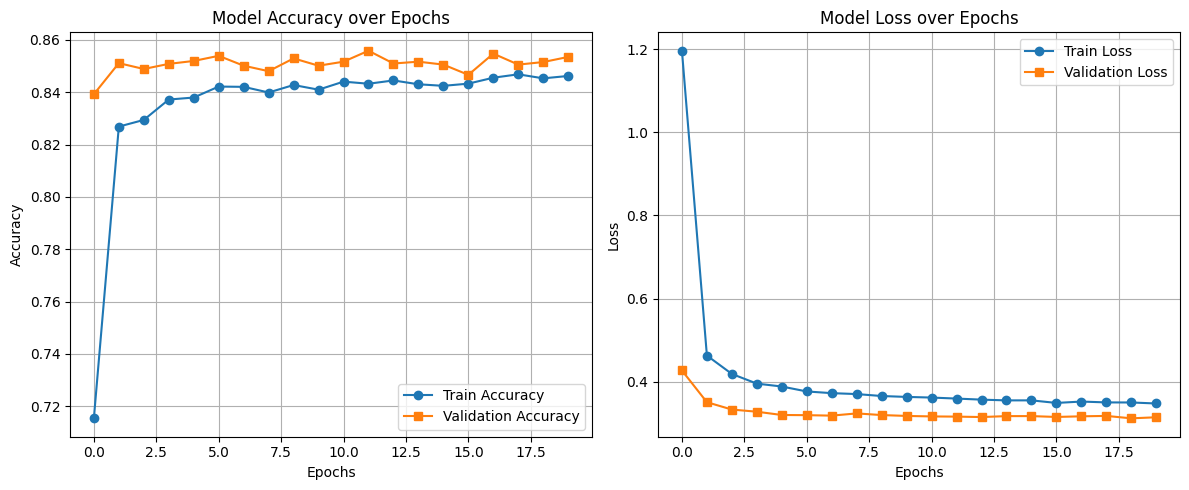

In [10]:
# Load Optuna study
study = optuna.load_study(
    study_name="DNN_diseases_symptoms_dropextremelymore1000withoutSMOTE_secondaugmented_study",
    storage="sqlite:///C:/Users/khiew/Downloads/dnn.db"
)

# Get best parameters
best_params = study.best_trial.params

# Rebuild model using best parameters
best_model = keras.Sequential()
best_model.add(layers.Input(shape=(input_dim,)))

for i in range(best_params['n_layers']):
    best_model.add(layers.Dense(best_params[f'n_units_{i}'], activation=best_params[f'activation_{i}']))
    best_model.add(layers.Dropout(best_params[f'dropout_rate_{i}']))

best_model.add(layers.Dense(num_classes, activation='softmax'))

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit the model and save training history
history = best_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

# ===========================
# Plotting Training Lifecycle
# ===========================

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

y_pred_test = np.argmax(best_model.predict(X_test), axis=1)
print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))


280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step
Classification Report on Test Set:
                                    precision    recall  f1-score   support

               acute bronchiolitis       0.76      0.97      0.85       247
                  acute bronchitis       0.71      0.83      0.77       249
                acute pancreatitis       1.00      0.74      0.85       257
                           anxiety       1.00      0.98      0.99       237
              arthritis of the hip       0.94      0.97      0.95       236
benign prostatic hyperplasia (bph)       0.69      1.00      0.82       238
                          bursitis       0.96      0.81      0.88       244
                     cholecystitis       0.71      0.95      0.81       233
    complex regional pain syndrome       0.89      0.83      0.86       258
                        concussion       1.00      0.97      0.98       217
     conjunctivitis due to allergy       0.93      0.96      0.94       210
         